# 03 – Post-process 2D output

Equivalent to `post_pro_rel_2D.ipynb`, but works even if the run was interrupted before the requested final time.

In [ ]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()


In [2]:
cd(@__DIR__)
include(joinpath("..","src","PIC.jl"))
using .PIC
using Plots
using Statistics
using FFTW
using FileIO, JLD2
using Printf


## Choose output file and load metadata

In [3]:
out_file = joinpath("..", "Results",
    "thermal_rel_sbp_J50x50_N5_Th3_alp1_o5.jld2")

data = load(out_file)
N, J, box, order = data["par_grid"]
t_i, t_f_target, M, M_g_target, dt = data["par_evolv"]
g = PICGrid(box, J, order)

# Detect how many snapshots were actually saved (handles interrupted runs)
tiempos = [k for k in 1:M_g_target if haskey(data, @sprintf("n_%05d", k))]
M_g = length(tiempos)
if M_g == 0
    error("No averaged snapshots found in ", out_file)
end
println("Requested M_g = ", M_g_target, ", actually saved = ", M_g)

# Physical time coordinate of each saved snapshot
out_every = div(M - 1, M_g_target - 1)
t_series = t_i .+ dt .* out_every .* (tiempos .- 1)

dx = differentials(g)
x_p = [dx[1] * (i - 1) for i in 1:J[1]]
y_p = [dx[2] * (i - 1) for i in 1:J[2]]

@show data["run_name"]


Requested M_g = 100, actually saved = 87
data["run_name"] = "thermal_rel_sbp_J50x50_N5_Th3_alp1_o5"


"thermal_rel_sbp_J50x50_N5_Th3_alp1_o5"

## Load averaged fields

In [4]:
avg = load_averages(out_file, g, M_g; indices=tiempos,
    fields=(:n, :S, :E, :B, :Energy_K, :Energy_E, :T, :Gauss_max, :Gauss_l2))

n_t   = avg[:n]      # (J1,J2,M_g)
S_t   = avg[:S]      # (2,J1,J2,M_g)
E_t   = avg[:E]      # (2,J1,J2,M_g)
B_t   = avg[:B]      # (J1,J2,M_g)
Energy_K = avg[:Energy_K][:]  # scalar per output
Energy_E = avg[:Energy_E][:]
T_t   = avg[:T][:]
Gauss_max = avg[:Gauss_max][:]
Gauss_l2 = avg[:Gauss_l2][:]

println("final t in series = ", t_series[end])


final t in series = 8.6


## Energy history

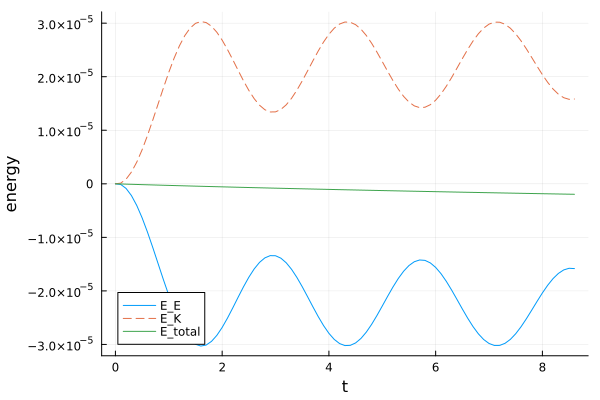

In [5]:
A = 100_000
plot(t_series, Energy_E .- Energy_E[1], label="E_E", xlabel="t", ylabel="energy")
plot!(t_series, (Energy_K .- Energy_K[1]), label="E_K", ls=:dash)
plot!(t_series, A*(Energy_E .+ Energy_K .- (Energy_E[1] + Energy_K[1])), label="E_total")


## Density spectrum at final saved time

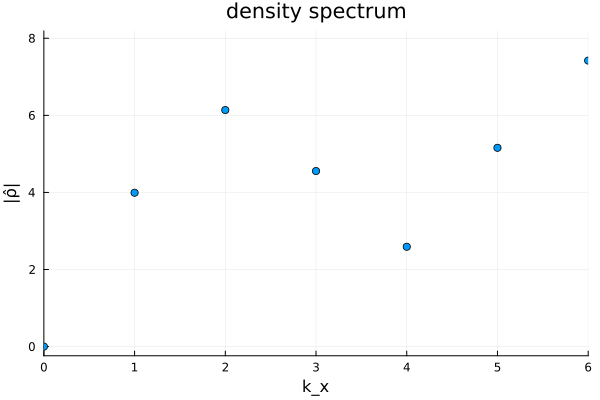

In [6]:
rho_f = rfft(n_t[:, :, M_g] .- 1.0)
freqs = rfftfreq(J[1], 1 / dx[1])
Plots.scatter(freqs, abs.(rho_f[:, 1]),
    title="density spectrum", xlabel="k_x", ylabel="|ρ̂|",
    xlim=(0, 6), label=false)


## Final density and fields

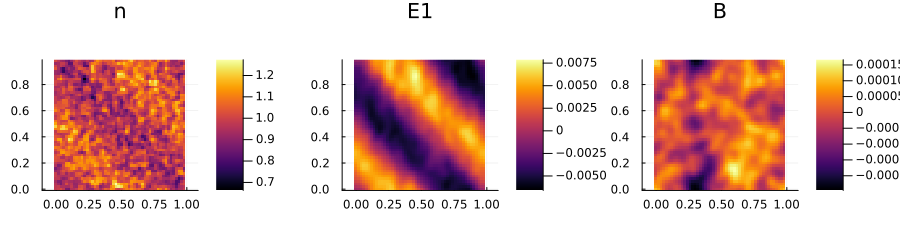

In [7]:
p1 = heatmap(x_p, y_p, n_t[:, :, M_g]', title="n", aspectratio=1)
p2 = heatmap(x_p, y_p, E_t[1, :, :, M_g]', title="E1", aspectratio=1)
p3 = heatmap(x_p, y_p, B_t[:, :, M_g]', title="B", aspectratio=1)
plot(p1, p2, p3, layout=(1, 3), size=(900, 250))


## Gauss law constraint history

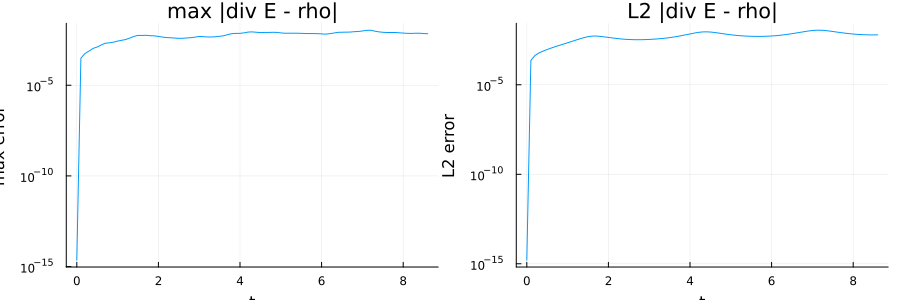

In [8]:
p1 = plot(t_series, Gauss_max, label=false, xlabel="t", ylabel="max error",
    title="max |div E - rho|", yscale=:log10)
p2 = plot(t_series, Gauss_l2, label=false, xlabel="t", ylabel="L2 error",
    title="L2 |div E - rho|", yscale=:log10)
plot(p1, p2, layout=(1, 2), size=(900, 300))


## Temperature history

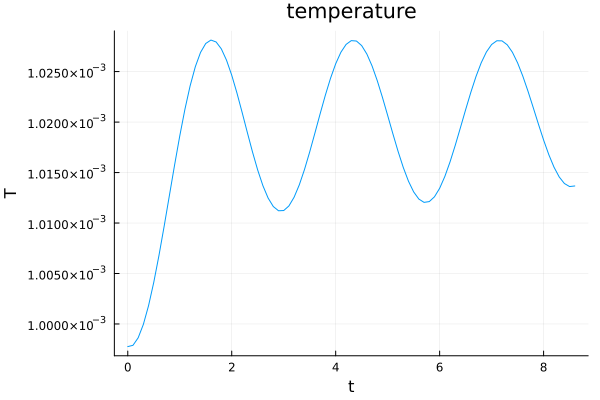

In [9]:
plot(t_series, T_t, xlabel="t", ylabel="T", title="temperature", label=false)
